# Baseline Model - AirBnB Classification

A simple ML pipeline demonstrating the essential components for building a predictive model.


### Setup and Imports

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error


RANDOM_SEED = 42

### Data Loading

In [84]:
try:
    la_df = pd.read_csv('/listings LA.csv')
    ny_df = pd.read_csv('/listings NYC.csv')
except:
    la_df = pd.read_csv('listings LA.csv')
    ny_df = pd.read_csv('listings NYC.csv')

la_cols = la_df.columns.values
ny_cols = ny_df.columns.values

la_df.head()

,last_scraped,name,description,neighborhood_overview,host_name,host_since,host_about,host_response_time,host_response_rate,host_acceptance_rate,...,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,estimated_occupancy_l365d,first_review,last_review,instant_bookable,review_scores_rating
0,2025-09-02,"Blueground | W. Hollywood, nr shops & melrose",Show up and start living from day one in Los A...,This furnished apartment is located in Melrose...,Blueground,2016-12-16,"We’re Blueground, a global proptech company wi...",within an hour,100%,97%,...,31.0,1125.0,1125.0,31.0,1125.0,0,NaN,NaN,t,NaN
1,2025-09-02,"Bright Open Space Near Beach, Marina and LAX",Welcome to this light-filled private guest hou...,NaN,Veronique,2014-03-19,As a former flight attendant with nearly 15 ye...,within an hour,100%,100%,...,2.0,365.0,365.0,2.0,365.0,126,2024-05-12,2025-08-24,f,5.0
2,2025-09-03,Dreamy Nights Near Hollywood & Highland Center,"We are located on the Hollywood Walk of Fame, ...",- Hollywood Walk of Fame - 0 miles (Right outs...,RoomPicks,2023-02-20,NaN,within an hour,100%,90%,...,1.0,1.0,1125.0,1.0,852.9,0,NaN,NaN,t,NaN
3,2025-09-02,Lovely home near the beach & pier,Forget your worries in this spacious and seren...,NaN,Sean,2014-06-07,NaN,within an hour,100%,100%,...,30.0,365.0,365.0,30.0,365.0,120,2025-06-26,2025-07-28,f,5.0
4,2025-09-02,Sunlit Two Bedroom + Office in Beachwood Canyon,An incredible retreat in the hills. Two bedroo...,NaN,Jena,2011-10-11,"After 15 years in NYC, I now live in Los Angel...",within a few hours,100%,60%,...,4.0,60.0,60.0,4.0,60.0,8,2023-03-18,2025-06-26,f,5.0



### Basic EDA

LA

In [85]:
la_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45886 entries, 0 to 45885
Data columns (total 39 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   last_scraped               45886 non-null  object 
 1   name                       45885 non-null  object 
 2   description                44917 non-null  object 
 3   neighborhood_overview      19936 non-null  object 
 4   host_name                  45863 non-null  object 
 5   host_since                 45862 non-null  object 
 6   host_about                 25397 non-null  object 
 7   host_response_time         35581 non-null  object 
 8   host_response_rate         35581 non-null  object 
 9   host_acceptance_rate       35887 non-null  object 
 10  host_is_superhost          44124 non-null  object 
 11  host_listings_count        45862 non-null  float64
 12  host_total_listings_count  45862 non-null  float64
 13  host_verifications         45862 non-null  obj

In [86]:
print("Missing values:")
print((nulls := la_df.isnull().sum())[nulls > 0])

Missing values:
name                             1
description                    969
neighborhood_overview        25950
host_name                       23
host_since                      24
host_about                   20489
host_response_time           10305
host_response_rate           10305
host_acceptance_rate          9999
host_is_superhost             1762
host_listings_count             24
host_total_listings_count       24
host_verifications              24
host_has_profile_pic            24
bathrooms                     8983
bathrooms_text                 110
bedrooms                      3039
beds                          9031
price                         9067
minimum_minimum_nights           9
maximum_minimum_nights           9
minimum_maximum_nights           9
maximum_maximum_nights           9
first_review                 12501
last_review                  12501
review_scores_rating         12501
dtype: int64


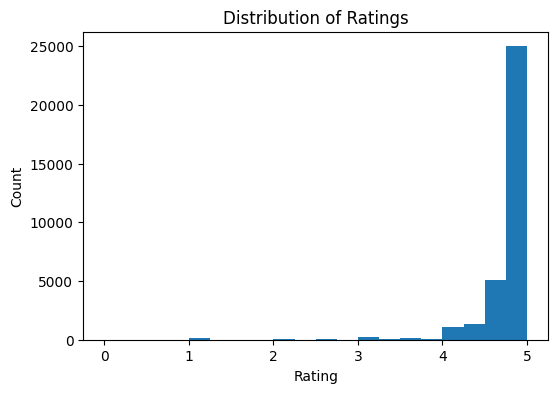

In [87]:
plt.figure(figsize=(6,4))
plt.hist(la_df['review_scores_rating'], bins=20)
plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Distribution of Ratings")
plt.show()

NY

In [88]:
ny_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36111 entries, 0 to 36110
Data columns (total 39 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   last_scraped               36111 non-null  object 
 1   name                       36109 non-null  object 
 2   description                35153 non-null  object 
 3   neighborhood_overview      18704 non-null  object 
 4   host_name                  34945 non-null  object 
 5   host_since                 34944 non-null  object 
 6   host_about                 19606 non-null  object 
 7   host_response_time         20337 non-null  object 
 8   host_response_rate         20337 non-null  object 
 9   host_acceptance_rate       20516 non-null  object 
 10  host_is_superhost          35727 non-null  object 
 11  host_listings_count        34944 non-null  float64
 12  host_total_listings_count  34944 non-null  float64
 13  host_verifications         34944 non-null  obj

In [89]:
print("Missing values:")
print((nulls := ny_df.isnull().sum())[nulls > 0])

Missing values:
name                             2
description                    958
neighborhood_overview        17407
host_name                     1166
host_since                    1167
host_about                   16505
host_response_time           15774
host_response_rate           15774
host_acceptance_rate         15595
host_is_superhost              384
host_listings_count           1167
host_total_listings_count     1167
host_verifications            1167
host_has_profile_pic          1167
bathrooms                    14411
bathrooms_text                 114
bedrooms                      5949
beds                         14468
price                        14783
minimum_minimum_nights          12
maximum_minimum_nights          12
minimum_maximum_nights          12
maximum_maximum_nights          12
first_review                 11188
last_review                  11188
review_scores_rating         11188
dtype: int64


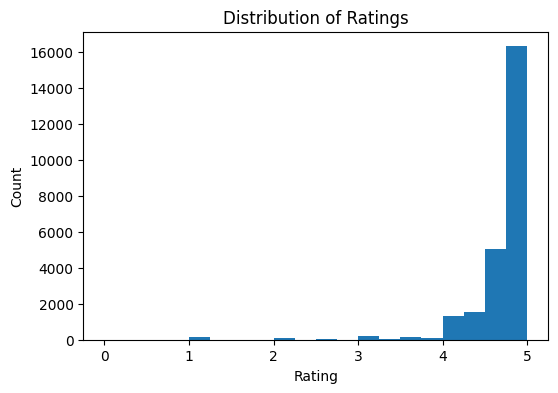

In [90]:
plt.figure(figsize=(6,4))
plt.hist(ny_df['review_scores_rating'], bins=20)
plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Distribution of Ratings")
plt.show()

### Preprocessing



In [91]:
la_df['city'] = 'LA'
ny_df['city'] = 'NY'
df = pd.concat([la_df, ny_df], ignore_index=True)
print(f'{df.duplicated().sum()} duplicate rows were removed.')
df = df.drop_duplicates()

50 duplicate rows were removed.


In [92]:
# datetime columns
date_cols = ['last_scraped', 'host_since', 'first_review', 'last_review']
df[date_cols] = df[date_cols].apply(pd.to_datetime, errors='coerce')

# numeric columns
numeric_cols = ['host_response_rate', 'host_acceptance_rate', 'price']
df[numeric_cols] = (df[numeric_cols].replace(r'\s*[$%,]\s*', '', regex=True).apply(pd.to_numeric, errors='coerce'))

# boolean columns
bool_cols = ['host_is_superhost', 'host_has_profile_pic', 'instant_bookable']
df[bool_cols] = df[bool_cols].replace({'t': True, 'f': False})

# list columns
df['host_verifications'] = df['host_verifications'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)
df['amenities'] = df['amenities'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

/tmp/ipython-input-3069909724.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[bool_cols] = df[bool_cols].replace({'t': True, 'f': False})


In [93]:
# removing entries without the dependent variable
cleaned_df = df.loc[df['review_scores_rating'].notna()]

# removing the cluster of entries without host information
cleaned_df = cleaned_df.loc[~(cleaned_df['host_name'].isna() | cleaned_df['host_since'].isna() | cleaned_df['host_verifications'].isna() | cleaned_df['host_has_profile_pic'].isna() | cleaned_df['host_total_listings_count'].isna() | cleaned_df['host_listings_count'].isna())]

# maximum / minimum nights
cleaned_df['minimum_minimum_nights'] = cleaned_df['minimum_minimum_nights'].fillna(cleaned_df['minimum_nights'])
cleaned_df['maximum_minimum_nights'] = cleaned_df['maximum_minimum_nights'].fillna(cleaned_df['minimum_nights'])
cleaned_df['minimum_maximum_nights'] = cleaned_df['minimum_maximum_nights'].fillna(cleaned_df['maximum_nights'])
cleaned_df['maximum_maximum_nights'] = cleaned_df['maximum_maximum_nights'].fillna(cleaned_df['maximum_nights'])

# Bathrooms
missing_rows = cleaned_df['bathrooms'].isna().sum()
cleaned_df['bathrooms'] = cleaned_df.groupby('bathrooms_text')['bathrooms'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x))
cleaned_df = cleaned_df.loc[cleaned_df['bathrooms'].notna()]

# Beds and bedrooms
cleaned_df['beds'] = cleaned_df.groupby('accommodates')['beds'].transform(lambda x: x.fillna(x.median()))
cleaned_df['bedrooms'] = cleaned_df.groupby('accommodates')['bedrooms'].transform(lambda x: x.fillna(x.median()))

# host stats imputation
cleaned_df['host_is_superhost_imputed'] = cleaned_df['host_is_superhost'].isna()
cleaned_df['host_is_superhost'] = cleaned_df['host_is_superhost'].fillna(False)
mapping_dict = {'within an hour': 1, 'within a few hours': 2, 'within a day': 3, 'a few days or more': 4}
cleaned_df['host_response_time_coded'] = cleaned_df['host_response_time'].map(mapping_dict).fillna(0)

for col in ['host_response_rate', 'host_acceptance_rate']:
    median_value = cleaned_df[col].median()
    cleaned_df[f'{col}_imputed'] = cleaned_df[col].isna()
    cleaned_df[col] = cleaned_df[col].fillna(median_value)

# free text to numeric data
cleaned_df['has_neighborhood_overview'] = cleaned_df['neighborhood_overview'].notna()
cleaned_df['has_host_about'] = cleaned_df['host_about'].notna()
cleaned_df['description_length_words'] = cleaned_df['description'].apply(lambda x: len(str(x).split()) if pd.notna(x) else 0)
cleaned_df['description_length_chars'] = cleaned_df['description'].apply(lambda x: len(str(x)) if pd.notna(x) else 0)


# Scaling to handle outliers
# prices
cleaned_df['log_price'] = np.log(cleaned_df['price'])
cleaned_df['log_price_imputed'] = cleaned_df['price'].isna()
cleaned_df['log_price'] = cleaned_df.groupby(['accommodates', 'city'])['log_price'].transform(lambda x: x.fillna(x.mean())) # originally - groupby(['accommodates', 'area']), changed it to city so it works without 'area'

# listings count -> log listings count
cleaned_df['log_host_total_listings_count'] = np.log(cleaned_df['host_total_listings_count'])
cleaned_df['log_host_listings_count'] = np.log(cleaned_df['host_listings_count'])


/tmp/ipython-input-1564964738.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cleaned_df['host_is_superhost'] = cleaned_df['host_is_superhost'].fillna(False)


In [94]:
redundant_columns = ['name', ' description', 'neighborhood_overview', 'host_name', 'host_about', 'host_response_time',
                     'host_verifications', ]



redundant_columns = df.columns[~df.dtypes.apply(lambda x: np.issubdtype(x, np.number))].tolist()
date_cols_to_keep = ['last_scraped', 'host_since', 'first_review', 'last_review']
redundant_columns_to_drop = [col for col in redundant_columns if col not in date_cols_to_keep]

# Also explicitly remove 'description' as it's been replaced by length features
redundant_columns_to_drop.append('description')

# Drop the identified redundant columns from cleaned_df
cleaned_df = cleaned_df.drop(columns=redundant_columns_to_drop, errors='ignore')

print("Columns removed:", redundant_columns_to_drop)
cleaned_df.head

Columns removed: ['name', 'description', 'neighborhood_overview', 'host_name', 'host_about', 'host_response_time', 'host_is_superhost', 'host_verifications', 'host_has_profile_pic', 'property_type', 'room_type', 'bathrooms_text', 'amenities', 'instant_bookable', 'city', 'description']


<bound method NDFrame.head of       last_scraped host_since  host_response_rate  host_acceptance_rate  \
1       2025-09-02 2014-03-19               100.0                 100.0   
3       2025-09-02 2014-06-07               100.0                 100.0   
4       2025-09-02 2011-10-11               100.0                  60.0   
5       2025-09-02 2011-07-04               100.0                 100.0   
6       2025-09-02 2024-04-09                77.0                  68.0   
...            ...        ...                 ...                   ...   
81992   2025-10-02 2016-06-02               100.0                  96.0   
81993   2025-10-02 2015-02-03               100.0                  96.0   
81994   2025-10-02 2018-10-21                88.0                  83.0   
81995   2025-10-02 2012-10-17               100.0                 100.0   
81996   2025-10-02 2019-11-04                60.0                  76.0   

       host_listings_count  host_total_listings_count   latitude   longitude  \
1                      4.0                       12.0  33.989461 -118.429896   
3                      1.0                        1.0  33.839786 -118.379923   
4                      1.0                        4.0  34.122659 -118.320372   
5                      1.0                        2.0  34.098200 -118.275900   
6                     98.0                      100.0  34.102920 -118.339040   
...                    ...                        ...        ...         ...   
81992                  1.0                        1.0  40.680990  -73.943330   
81993                  1.0                        1.0  40.721080  -74.003460   
81994                  2.0                        5.0  40.809910  -73.939100   
81995                  3.0                        4.0  40.764720  -73.926400   
81996                  2.0                        8.0  40.759010  -73.983880   

       accommodates  bathrooms  ...  host_response_rate_imputed  \
1                 2        1.0  ...                       False   
3                 6        2.5  ...                       False   
4                 4        3.0  ...                       False   
5                 2        1.0  ...                        True   
6                 2        1.0  ...                       False   
...             ...        ...  ...                         ...   
81992             6        3.0  ...                       False   
81993             2        1.5  ...                        True   
81994             2        1.0  ...                       False   
81995             2        1.0  ...                       False   
81996             4        2.0  ...                       False   

       host_acceptance_rate_imputed  has_neighborhood_overview  \
1                             False                      False   
3                             False                      False   
4                             False                      False   
5                             False                       True   
6                             False                      False   
...                             ...                        ...   
81992                          True                       True   
81993                          True                      False   
81994                         False                       True   
81995                         False                       True   
81996                         False                       True   

       has_host_about  description_length_words  description_length_chars  \
1                True                        71                       439   
3               False                         9                        53   
4                True                        61                       365   
5                True                        82                       471   
6               False                        18                       101   
...               ...                       ... 

In [95]:
cleaned_df.head()

,last_scraped,host_since,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,...,host_response_rate_imputed,host_acceptance_rate_imputed,has_neighborhood_overview,has_host_about,description_length_words,description_length_chars,log_price,log_price_imputed,log_host_total_listings_count,log_host_listings_count
1,2025-09-02,2014-03-19,100.0,100.0,4.0,12.0,33.989461,-118.429896,2,1.0,...,False,False,False,True,71,439,4.955827,False,2.484907,1.386294
3,2025-09-02,2014-06-07,100.0,100.0,1.0,1.0,33.839786,-118.379923,6,2.5,...,False,False,False,False,9,53,6.003887,False,0.000000,0.000000
4,2025-09-02,2011-10-11,100.0,60.0,1.0,4.0,34.122659,-118.320372,4,3.0,...,False,False,False,True,61,365,6.163315,False,1.386294,0.000000
5,2025-09-02,2011-07-04,100.0,100.0,1.0,2.0,34.098200,-118.275900,2,1.0,...,True,False,True,True,82,471,4.795791,False,0.693147,0.000000
6,2025-09-02,2024-04-09,77.0,68.0,98.0,100.0,34.102920,-118.339040,2,1.0,...,False,False,False,False,18,101,3.258097,False,4.605170,4.584967


In [96]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 58044 entries, 1 to 81996
Data columns (total 37 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   last_scraped                   58044 non-null  datetime64[ns]
 1   host_since                     58044 non-null  datetime64[ns]
 2   host_response_rate             58044 non-null  float64       
 3   host_acceptance_rate           58044 non-null  float64       
 4   host_listings_count            58044 non-null  float64       
 5   host_total_listings_count      58044 non-null  float64       
 6   latitude                       58044 non-null  float64       
 7   longitude                      58044 non-null  float64       
 8   accommodates                   58044 non-null  int64         
 9   bathrooms                      58044 non-null  float64       
 10  bedrooms                       58044 non-null  float64       
 11  beds                

### Train/Test Split


In [97]:
X = cleaned_df.drop("review_scores_rating", axis=1)
y = cleaned_df["review_scores_rating"]

In [98]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 46435 samples
Test set: 11609 samples


### Training a model

In [99]:
# Train a DummyRegressor as a baseline for regression
model = DummyRegressor(strategy="mean")
model.fit(X_train, y_train)

DummyRegressor()

### Evaluation


In [100]:
# Training set performance
y_train_pred = model.predict(X_train)

print("MAE:", mean_absolute_error(y_train, y_train_pred))
print("RMSE:", mean_squared_error(y_train, y_train_pred))

MAE: 0.2469862489805462
RMSE: 0.1913660897696048


In [101]:
# Test set performance
y_test_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("RMSE:", mean_squared_error(y_test, y_test_pred))

MAE: 0.24840300753575784
RMSE: 0.1914308162195487
